--- 
## Analyse Descriptive Univariée

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [87]:
df = pd.read_excel("Base_ER_FR.xlsx")
df.columns

Observations initiales : 100000


Index(['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET',
       'E_EAD', 'E_OFF', 'E_ONB', 'MREVAU', 'MREVNU', 'MREVTOT', 'MTECH',
       'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx', 'Unnamed: 19'],
      dtype='str')

In [88]:
print("Observations initiales :", len(df))
df = df.drop(columns=["Unnamed: 19"])

Observations initiales : 100000


VARIABLE ID : identifiant unique associe a chaque observation

VARIABLE AGE_CLI : age du client

In [4]:
df["AGE_CLI"].describe(percentiles=[0.25, 0.5, 0.75])

count    99524.000000
mean        51.958472
std         14.941231
min         18.000000
25%         40.000000
50%         52.000000
75%         64.000000
max         92.000000
Name: AGE_CLI, dtype: float64

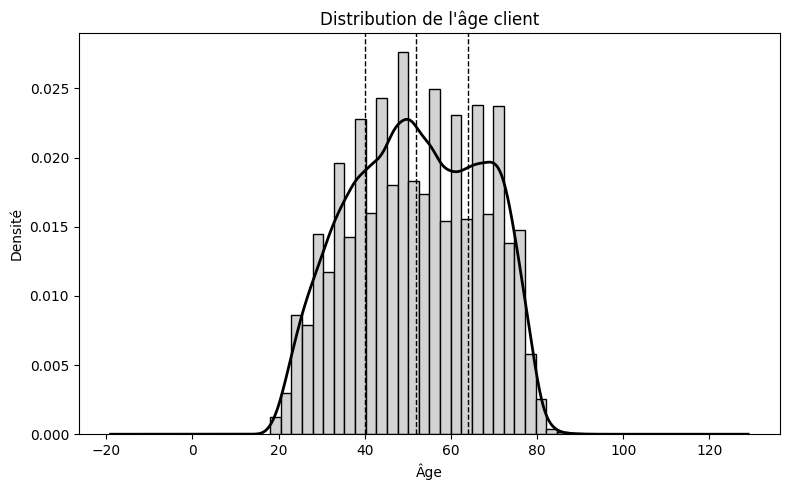

In [5]:
age = df["AGE_CLI"].dropna()

# quartiles
q25, q50, q75 = np.percentile(age, [25, 50, 75])


plt.figure(figsize=(8, 5))
plt.hist(age, bins=30, density=True, color="lightgrey", edgecolor="black")

age.plot(kind="density", color="black", linewidth=2)
plt.axvline(q25, linestyle="--", color="black", linewidth=1)
plt.axvline(q50, linestyle="--", color="black", linewidth=1)
plt.axvline(q75, linestyle="--", color="black", linewidth=1)
plt.title("Distribution de l'âge client")
plt.xlabel("Âge")
plt.ylabel("Densité")
plt.tight_layout()
plt.show()


In [6]:
print(
    f"L'âge des clients est compris entre {int(age.min())} et {int(age.max())} ans. "
    f"La distribution est centrée autour de {int(q50)} ans, avec des premier et "
    f"troisième quartiles respectivement égaux à {int(q25)} et {int(q75)} ans. "
)


L'âge des clients est compris entre 18 et 92 ans. La distribution est centrée autour de 52 ans, avec des premier et troisième quartiles respectivement égaux à 40 et 64 ans. 


VARIABLE B_MAT : maturite initiale du credit, exprimee en mois

In [7]:
df["B_MAT"].describe(percentiles=[0.25, 0.5, 0.75])

count    98620.000000
mean        70.807585
std         43.506068
min          0.000000
25%         48.000000
50%         61.000000
75%         78.250000
max        300.000000
Name: B_MAT, dtype: float64

Traitement valeur extrême :

In [89]:
#utilisation regle IQR
Q1 = df["B_MAT"].quantile(0.25)
Q3 = df["B_MAT"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df = df[df["B_MAT"] <= upper_bound]


In [96]:
print("Observations après traitement :", len(df))
print("Observations supprimées :", 100000 - len(df))
print("Taux de suppression (%) :", round((100000 - len(df)) / 100000 * 100, 2), "%")

Observations après traitement : 85648
Observations supprimées : 14352
Taux de suppression (%) : 14.35 %


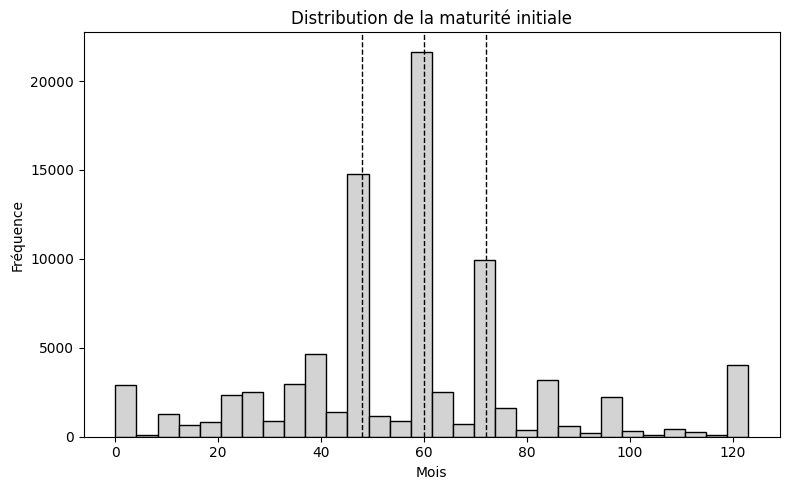

In [9]:
bmat = df["B_MAT"].dropna()
q25, q50, q75 = np.percentile(bmat, [25, 50, 75])


plt.figure(figsize=(8, 5))
plt.hist(bmat, bins=30, color="lightgrey", edgecolor="black")
plt.axvline(q25, linestyle="--", color="black", linewidth=1)
plt.axvline(q50, linestyle="--", color="black", linewidth=1)
plt.axvline(q75, linestyle="--", color="black", linewidth=1)
plt.title("Distribution de la maturité initiale")
plt.xlabel("Mois")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

VARIABLE B_RESMAT : maturite residuelle du credit (duree restante jusqu’a l’echeance d’un
credit), exprimee en mois

In [10]:
df["B_RESMAT"].describe(percentiles=[0.25, 0.5, 0.75])

count    85648.000000
mean        27.715732
std         24.200356
min          0.000000
25%          6.000000
50%         23.000000
75%         43.000000
max        119.000000
Name: B_RESMAT, dtype: float64

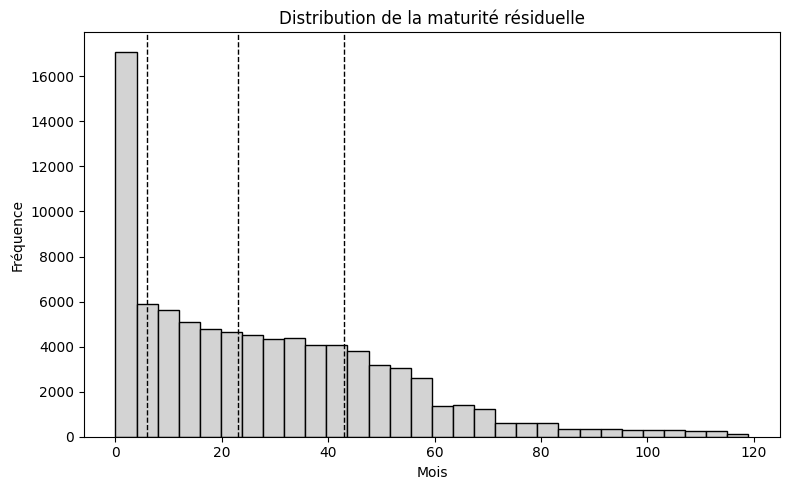

In [11]:
bresmat = df["B_RESMAT"].dropna()
q25, q50, q75 = np.percentile(bresmat, [25, 50, 75])

plt.figure(figsize=(8, 5))
plt.hist(bresmat, bins=30, color="lightgrey", edgecolor="black")
plt.axvline(q25, linestyle="--", color="black", linewidth=1)
plt.axvline(q50, linestyle="--", color="black", linewidth=1)
plt.axvline(q75, linestyle="--", color="black", linewidth=1)
plt.title("Distribution de la maturité résiduelle")
plt.xlabel("Mois")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

VARIABLE CLASSACT : classe d'actif

VARIABLE CSP : catégorie socio profesionnel (regroupement à traiter)

VARIABLE DARRET : date d’arret ou de reference associee au credit.

In [12]:
df["DARRET"] = pd.to_datetime(
    df["DARRET"].astype(str),
    format="%Y%m",
    errors="coerce"
)
df["DARRET"].describe()


count                         85648
mean     2021-03-03 11:17:05.593125
min             2019-01-01 00:00:00
25%             2019-12-01 00:00:00
50%             2021-02-01 00:00:00
75%             2022-05-01 00:00:00
max             2023-12-01 00:00:00
Name: DARRET, dtype: object

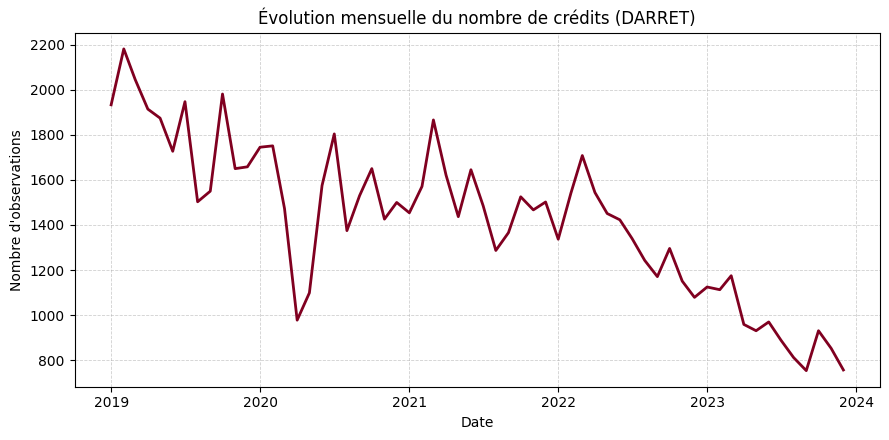

In [13]:
monthly_counts = (
    df
    .groupby(df["DARRET"].dt.to_period("M").dt.to_timestamp())
    .size()
    .reset_index(name="n_obs")
    .rename(columns={"DARRET": "DARRET_M"})
)

plt.figure(figsize=(9, 4.5))

plt.plot(
    monthly_counts["DARRET_M"],
    monthly_counts["n_obs"],
    color="#800020",      # bordeaux
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Nombre d'observations")
plt.title("Évolution mensuelle du nombre de crédits (DARRET)")

plt.grid(
    which="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.6
)

plt.tight_layout()
plt.show()


VARIABLE E_EAD :  exposition au defaut du contrat 

In [14]:
df["E_EAD"].describe(percentiles=[0.25, 0.5, 0.75])

count     85648.000000
mean        598.232829
std        3284.816040
min           0.000000
25%           0.000000
50%           0.000000
75%           0.150000
max      226089.670000
Name: E_EAD, dtype: float64

<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_7439/686561068.py:18: SyntaxWarning: invalid escape sequence '\l'
  plt.title("Distribution de $\log_{10}(E\_EAD)$ (E_EAD > 0)")


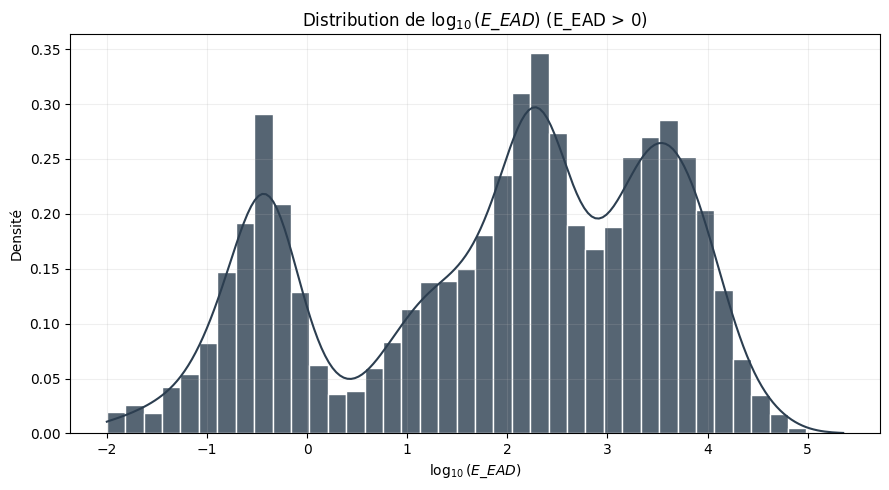

In [15]:
ead1 = df.loc[df["E_EAD"] > 0, "E_EAD"]
logead1 = np.log10(ead1)

plt.figure(figsize=(9, 5))

sns.histplot(
    logead1,
    bins=40,
    stat="density",
    kde=True,
    color="#2C3E50",
    edgecolor="white",
    alpha=0.8
)

plt.xlabel(r"$\log_{10}(E\_EAD)$")
plt.ylabel("Densité")
plt.title("Distribution de $\log_{10}(E\_EAD)$ (E_EAD > 0)")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


VARIABLE E_OFF : exposition hors bilan associee au credit

In [16]:
df["E_OFF"].describe()

count    85648.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: E_OFF, dtype: float64

VARIABLE E_ONB : montant du bilan

In [17]:
(df["E_ONB"].fillna(0) == df["E_EAD"].fillna(0)).all()


np.True_

VARIABLE MREVAU : montant autre revenu client

In [18]:
df["MREVAU"].describe(percentiles=[0.25, 0.5, 0.75])

count     85602.000000
mean         95.098771
std         902.758234
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      194096.000000
Name: MREVAU, dtype: float64

VARIABLE MREVNU : montant du revenu du client

In [19]:
df["MREVNU"].describe(percentiles=[0.25, 0.5, 0.75])

count     85602.000000
mean       2470.920481
std        2948.580207
min           0.000000
25%        1538.000000
50%        2020.000000
75%        2800.000000
max      265000.000000
Name: MREVNU, dtype: float64

VARIABLE MREVTOT :  montant du revenu total du client

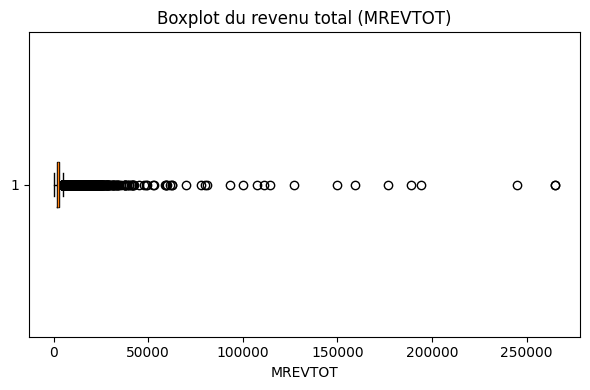

In [20]:
mrevtot = df["MREVTOT"].dropna()
plt.figure(figsize=(6, 4))
plt.boxplot(
    mrevtot,
    vert=False,
    showfliers=True
)
plt.xlabel("MREVTOT")
plt.title("Boxplot du revenu total (MREVTOT)")

plt.tight_layout()
plt.show()

VARIABLE MTECH : montant de l’echeance theorique du credit (le paiement periodique contractuel que le client est cense verser a chaque echeance (mensualite), hors evenement particulier)

In [21]:
df["MTECH"].describe(percentiles=[0.25, 0.5, 0.75])

count    85648.000000
mean       219.551147
std        249.821334
min          0.000000
25%         95.270000
50%        176.455000
75%        286.815000
max      35915.740000
Name: MTECH, dtype: float64

VARIABLE NBIMP :  nombre d’impayes observes sur le credit.

In [22]:
df["NBIMP"].describe(percentiles=[0.25, 0.5, 0.75])

count    85648.000000
mean         0.006608
std          0.132351
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         21.000000
Name: NBIMP, dtype: float64

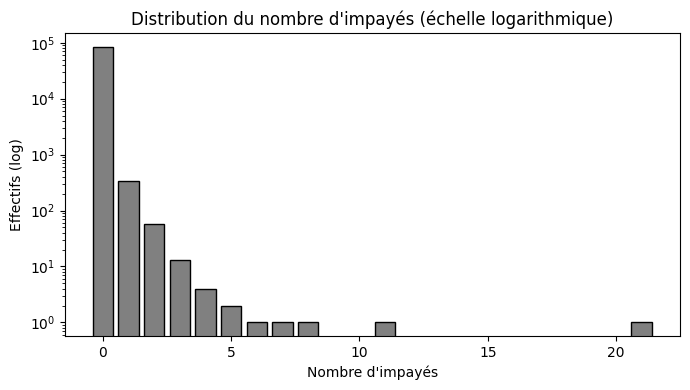

In [23]:
nbimp_counts = df["NBIMP"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(
    nbimp_counts.index,
    nbimp_counts.values,
    color="gray",
    edgecolor="black"
)

plt.yscale("log")
plt.xlabel("Nombre d'impayés")
plt.ylabel("Effectifs (log)")
plt.title("Distribution du nombre d'impayés (échelle logarithmique)")

plt.tight_layout()
plt.show()

VARIABLE NB_ECH : nombre total d’echeances prevues par le contrat.

In [24]:
df["NB_ECH"].describe(percentiles=[0.25, 0.5, 0.75])  

count    85648.000000
mean        51.531046
std         26.886706
min          1.000000
25%         36.000000
50%         49.000000
75%         62.000000
max        163.000000
Name: NB_ECH, dtype: float64

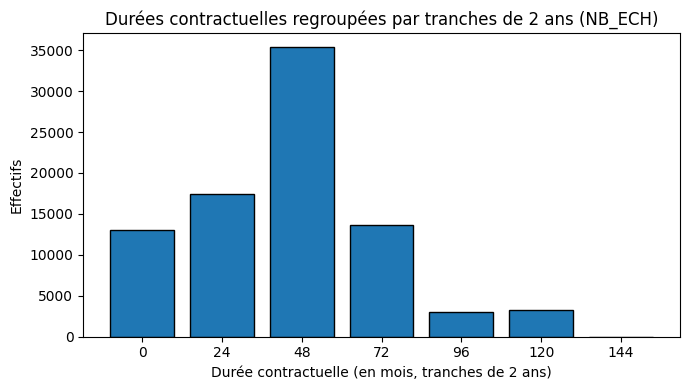

In [25]:
nb_ech_2y_counts = (
    (df["NB_ECH"] // 24 * 24)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 4))

plt.bar(
    nb_ech_2y_counts.index.astype(str),
    nb_ech_2y_counts.values,
    edgecolor="black"
)

plt.xlabel("Durée contractuelle (en mois, tranches de 2 ans)")
plt.ylabel("Effectifs")
plt.title("Durées contractuelles regroupées par tranches de 2 ans (NB_ECH)")

plt.tight_layout()
plt.show()


VARIABLE produit :  type de produit de credit

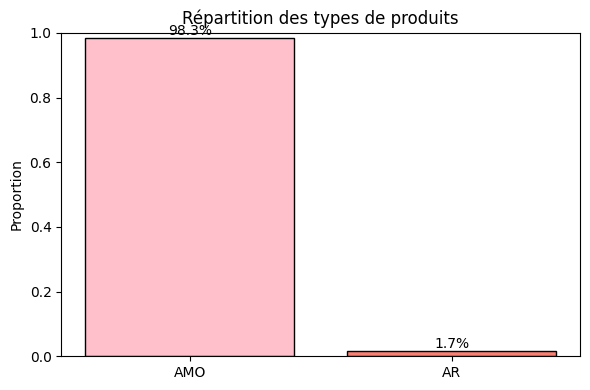

In [26]:
prod_counts = df["produit"].value_counts()
prod_props = prod_counts / prod_counts.sum()


plt.figure(figsize=(6, 4))
bars = plt.bar(
    prod_props.index,
    prod_props.values,
    color=["pink", "salmon"],
    edgecolor="black"
)

plt.ylabel("Proportion")
plt.title("Répartition des types de produits")

for bar, val in zip(bars, prod_props.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val,
        f"{val*100:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 1)
plt.tight_layout()
plt.show()


VARIABLE RA :  montant du remboursement anticipe observe sur le credit

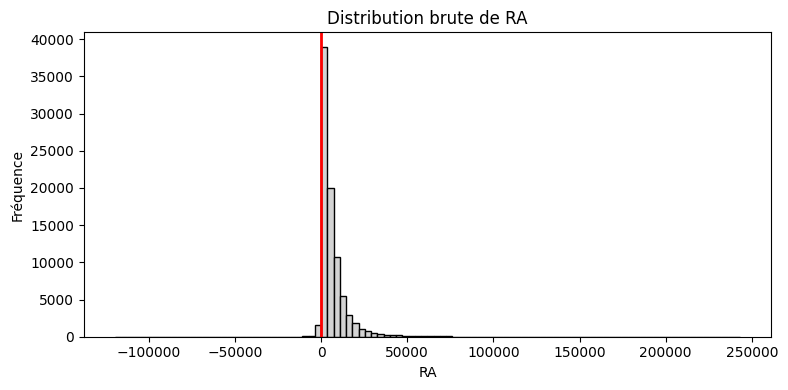

In [27]:
ra = df["RA"].dropna()

plt.figure(figsize=(8, 4))

plt.hist(
    ra,
    bins=100,
    color="lightgrey",
    edgecolor="black"
)

# Ligne verticale en zéro
plt.axvline(0, color="red", linewidth=2)

plt.xlabel("RA")
plt.ylabel("Fréquence")
plt.title("Distribution brute de RA")

plt.tight_layout()
plt.show()

VARIABLE Tx :  correspond au taux d’interet contractuel du credit

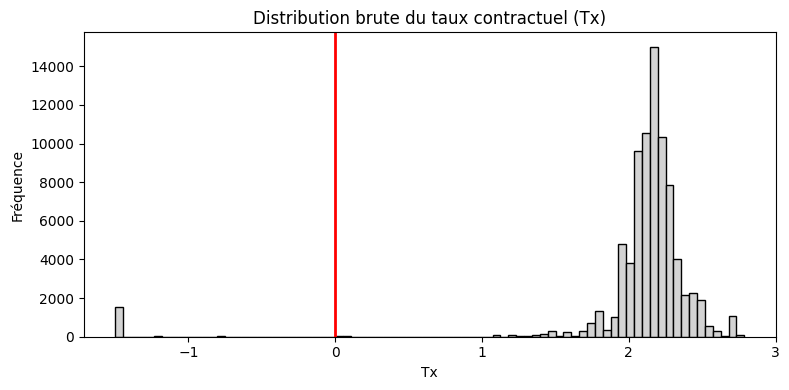

In [28]:
tx = df["Tx"].dropna()

plt.figure(figsize=(8, 4))

plt.hist(
    tx,
    bins=80,
    color="lightgrey",
    edgecolor="black"
)

# Ligne verticale en zéro (taux négatifs)
plt.axvline(0, color="red", linewidth=2)

plt.xlabel("Tx")
plt.ylabel("Fréquence")
plt.title("Distribution brute du taux contractuel (Tx)")

plt.tight_layout()
plt.show()

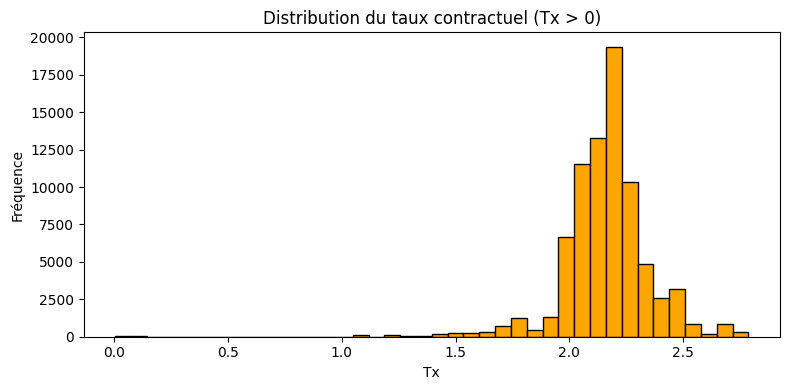

In [29]:
# Restriction aux taux strictement positifs
tx_pos = tx[tx > 0]

plt.figure(figsize=(8, 4))

plt.hist(
    tx_pos,
    bins=40,
    color="orange",
    edgecolor="black"
)

plt.xlabel("Tx")
plt.ylabel("Fréquence")
plt.title("Distribution du taux contractuel (Tx > 0)")

plt.tight_layout()
plt.show()


--- 

## Traitement des valeurs manquantes :

In [30]:
na_table = pd.DataFrame({
    "nb_na": df.isna().sum(),
    "pourcentage_na": df.isna().mean()
}).sort_values("pourcentage_na", ascending=False)

na_table

,nb_na,pourcentage_na
Tx,4751,0.055471
CSP,2459,0.028711
AGE_CLI,456,0.005324
MREVTOT,46,0.000537
MREVAU,46,0.000537
MREVNU,46,0.000537
ID,0,0.000000
B_MAT,0,0.000000
DARRET,0,0.000000
CLASSACT,0,0.000000


In [31]:
df2 = df.copy()

drop = [
    "ID",          # identifiant technique
    "E_OFF",       # variable dégénérée
    "E_ONB",       # colinéaire parfaite avec E_EAD
    "CLASSACT"     # déséquilibre extrême, non discriminante
]

df2 = df2.drop(columns=drop, errors="ignore")

In [50]:
# Création d'une nouvelle variable sans incohérence de valeurs négatives du remboursement anticipé
df2["RA2"] = df2["RA"].clip(lower=0)

#TRAITEMENT DES VALEURS MANQUANTES
# Age
df2["AGE_CLI"] = df2["AGE_CLI"].fillna(df2["AGE_CLI"].median())

# CSP
df2["CSP"] = df2["CSP"].fillna("Inconnu")

# Taux : on garde uniquement taux positifs
df2 = df2[df2["Tx"] > 0]

# Imputation médiane Tx (après filtrage)
df2["Tx"] = df2["Tx"].fillna(df2["Tx"].median())

# Maturité initiale
df2["B_MAT"] = df2["B_MAT"].fillna(df2["B_MAT"].median())

# Maturité résiduelle
df2["B_RESMAT"] = df2["B_RESMAT"].fillna(df2["B_RESMAT"].median())
df2.loc[df2["B_RESMAT"] < 0, "B_RESMAT"] = 0

# Revenu
for v in ["MREVNU", "MREVAU", "MREVTOT"]:
    df2[v] = df2[v].fillna(df2[v].median())

df2 = df2[df2["E_EAD"].notna()]

#Cohérence maturité
# On enlève les maturités nulles
df2 = df2[df2["B_MAT"] > 0]

# On corrige cas incohérents
df2.loc[df2["B_RESMAT"] > df2["B_MAT"], "B_RESMAT"] = df2["B_MAT"]


In [51]:
df2.isna().sum().sort_values(ascending=False)


AGE_CLI        0
B_MAT          0
B_RESMAT       0
CSP            0
DARRET         0
E_EAD          0
MREVAU         0
MREVNU         0
MREVTOT        0
MTECH          0
NBIMP          0
NB_ECH         0
produit        0
RA             0
Tx             0
RA2            0
CSP_grp        0
DARRET_M       0
IMP            0
log_EAD        0
DTI_proxy      0
Tx_spread      0
B_RESMAT_2Y    0
dtype: int64

Quantification du traitement des NAs

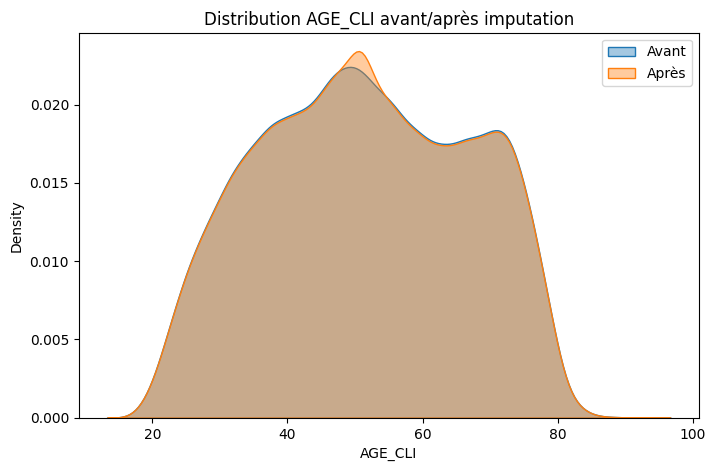

In [80]:
plt.figure(figsize=(8,5))

sns.kdeplot(df["AGE_CLI"], label="Avant", fill=True, alpha=0.4)
sns.kdeplot(df2["AGE_CLI"], label="Après", fill=True, alpha=0.4)

plt.title("Distribution AGE_CLI avant/après imputation")
plt.legend()
plt.show()


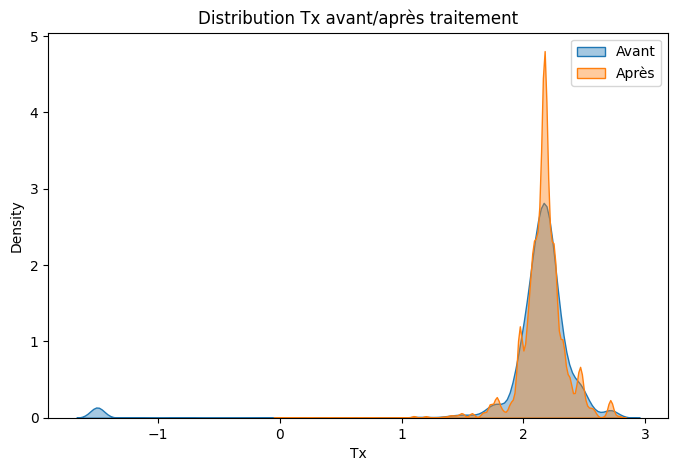

In [81]:
plt.figure(figsize=(8,5))

sns.kdeplot(df["Tx"], label="Avant", fill=True, alpha=0.4)
sns.kdeplot(df2["Tx"], label="Après", fill=True, alpha=0.4)

plt.title("Distribution Tx avant/après traitement")
plt.legend()
plt.show()


In [ ]:

print("Observations après nettoyage :", len(df2))
print("Observations supprimées :", len(df) - len(df2))
print("Taux de suppression (%) :", round((len(df) - len(df2)) / len(df) * 100, 2))


Observations initiales : 85648
Observations après nettoyage : 85646
Observations supprimées : 2
Taux de suppression (%) : 0.0


--- 
## Création de Variables Cohérentes + TEST fonctiin de survie

Regroupement CSP (essaie)

In [ ]:
csp_map = {
    # SALARIÉS 
    70.0: "SALARIE",
    52.0: "SALARIE",
    46.0: "SALARIE",
    47.0: "SALARIE",
    48.0: "SALARIE",
    54.0: "SALARIE",
    55.0: "SALARIE",
    56.0: "SALARIE",
    36.0: "SALARIE",
    31.0: "SALARIE",
    32.0: "SALARIE",
    45.0: "SALARIE",
    53.0: "SALARIE",

    # INACTIFS
    60.0: "INACTIF",
    64.0: "INACTIF",

    # INDÉPENDANTS / AUTRES ACTIFS
    42.0: "INDEPENDANT",
    82.0: "INDEPENDANT",
    87.0: "INDEPENDANT",
    23.0: "INDEPENDANT"
}

df2["CSP_grp"] = df2["CSP"].map(csp_map)
df2["CSP_grp"] = df2["CSP_grp"].fillna("AUTRE")


csp_check = (
    df2["CSP_grp"]
    .value_counts(dropna=False)
    .to_frame("effectifs")
)
csp_check["pourcentage"] = 100 * csp_check["effectifs"] / len(df2)
csp_check



,effectifs,pourcentage
CSP_grp,,
SALARIE,67138,78.388287
INACTIF,9658,11.276387
AUTRE,5598,6.536055
INDEPENDANT,3254,3.799271


In [64]:
#Création de DARRET_M pour un effet mensuel
df2["DARRET_M"] = df2["DARRET"].dt.to_period("M").astype(str)

#Création de IMP qui indique si le client a eu au moins un impayé
df2["IMP"] = (df2["NBIMP"] > 0).astype(int)

#log de E_EAD pour réduire l'effet des valeurs extrêmes
df2["log_EAD"] = np.log1p(df2["E_EAD"])

eps = 1.0  # 1€ pour éviter divisions instables
df2["DTI_raw"] = df2["MTECH"] / (df2["MREVTOT"] + eps)

# bornage robuste (1%–99%)
lo, hi = df2["DTI_raw"].quantile([0.01, 0.99])
df2["DTI_w"] = df2["DTI_raw"].clip(lo, hi)

# transformation
df2["log_DTI"] = np.log1p(df2["DTI_w"])


#Spread du taux par rapport à la médiane
tx_ref = df2["Tx"].median()
df2["Tx_spread"] = df2["Tx"] - tx_ref

# Regroupement de NB_ECH en tranches de 2 ans (24 mois) (pas obligé mais on peut tester)
df2["B_RESMAT_2Y"] = (df2["B_RESMAT"] // 24) * 24

df2["Montant_credit"] = df2["NB_ECH"] * df2["MTECH"]



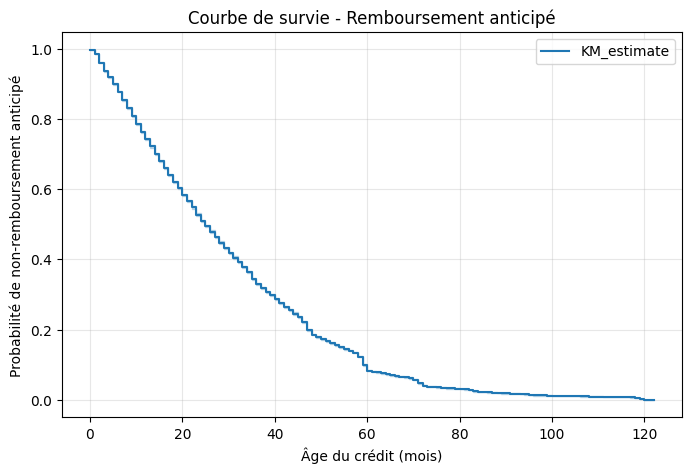

PD 12 mois estimée : 0.2573


In [61]:
from lifelines import KaplanMeierFitter
# Durée observée = âge du crédit au moment DARRET
df2["age_credit"] = df2["B_MAT"] - df2["B_RESMAT"]

# On garde uniquement durées cohérentes
df2 = df2[df2["age_credit"] >= 0]

# Evénement : remboursement anticipé observé
df2["event_RA"] = (df2["RA2"] > 0).astype(int)

kmf = KaplanMeierFitter()

T = df2["age_credit"]
E = df2["event_RA"]

kmf.fit(T, event_observed=E)

plt.figure(figsize=(8,5))
kmf.plot_survival_function()
plt.title("Courbe de survie - Remboursement anticipé")
plt.xlabel("Âge du crédit (mois)")
plt.ylabel("Probabilité de non-remboursement anticipé")
plt.grid(alpha=0.3)
plt.show()


pd_12 = 1 - kmf.survival_function_at_times(12).values[0]
print("PD 12 mois estimée :", round(pd_12,4))

In [65]:
from lifelines import CoxPHFitter

# 1) Evénement significatif (seuil au 90e percentile, à adapter)
thr = df2["RA2"].quantile(0.90)
df2["event_RA_sig"] = (df2["RA2"] >= thr).astype(int)

# 2) Dataset Cox
cox_vars = ["age_credit", "event_RA_sig", "Tx_spread", "log_DTI", "IMP", "log_EAD"]
df_cox2 = df2[cox_vars].dropna()

cph2 = CoxPHFitter()
cph2.fit(df_cox2, duration_col="age_credit", event_col="event_RA_sig")
cph2.print_summary()

# 3) Vérif PH
cph2.check_assumptions(df_cox2, p_value_threshold=0.05, show_plots=False)

# 4) Survie baseline (utile pour PD sur horizon)
baseline_S = cph2.baseline_survival_
print(baseline_S.head())


<lifelines.CoxPHFitter: fitted with 85646 total observations, 77081 right-censored observations>
             duration col = 'age_credit'
                event col = 'event_RA_sig'
      baseline estimation = breslow
   number of observations = 85646
number of events observed = 8565
   partial log-likelihood = -87485.01
         time fit was run = 2026-02-15 13:32:03 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Tx_spread -0.32      0.73      0.05           -0.42           -0.21                0.66                0.81
log_DTI    0.14      1.15      0.01            0.12            0.16                1.13                1.18
IMP       -1.39      0.25      0.71           -2.77            0.00                0.06                1.00
log_EAD   -0.11      0.89      0.01           -0.12           -0.10                0.88                0.90

           cmp to      z      p  -log2(p)
covariate                                
Tx_spread    0.00  -5.98 <0.005     28.71
log_DTI      0.00  12.45 <0.005    115.85
IMP          0.00  -1.96   0.05      4.31
log_EAD      0.00 -20.54 <0.005    309.05
---
Concordance = 0.66
Partial AIC = 174978.03
log-likelihood ratio test = 691.63 on 4 df
-log2(p) of ll-ratio test = 490.47

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'Tx_spread' failed the non-proportional test: p-value is 0.0172.

   Advice 1: the functional form of the variable 'Tx_spread' might be incorrect. That is, there may
be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'Tx_spread' using pd.cut, and then specify it in
`strata=['Tx_spread', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'log_DTI' failed the non-proportional test: p-value is 0.0204.

   Advice 1: the functional form of the variable 'log_DTI' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a function

In [ ]:
import numpy as np

LGD = 0.45
annual_df = 0.02
r_m = (1 + annual_df)**(1/12) - 1

# Horizon
T_max = int(np.nanmax(df_cox["age_credit"]))
T_max = min(T_max, 180)  # borne prudente 15 ans
T_grid = np.arange(1, T_max + 1)

# -----------------------------
# 1) Baseline survival S0(t)
# -----------------------------
S0_df = cph.baseline_survival_

# Interpolation linéaire sur la grille
S0_t = np.interp(
    T_grid,
    S0_df.index.values,
    S0_df.iloc[:, 0].values
)

# -----------------------------
# 2) Risque individuel exp(xβ)
# -----------------------------
X = df_cox[["Tx_spread", "log_DTI", "IMP", "log_EAD"]].values
beta = cph.params_.values
risk = np.exp(X @ beta)

# -----------------------------
# 3) Survie individuelle
# -----------------------------
S_it = np.power(S0_t[None, :], risk[:, None])

# -----------------------------
# 4) PD marginale mensuelle
# -----------------------------
S0_prev = np.concatenate([[1.0], S0_t[:-1]])
S_prev_it = np.power(S0_prev[None, :], risk[:, None])

p_it = S_prev_it - S_it

# -----------------------------
# 5) Discount factor
# -----------------------------
DF_t = 1 / np.power(1 + r_m, T_grid)

# -----------------------------
# 6) EAD constant
# -----------------------------
EAD_i = df2.loc[df_cox.index, "E_EAD"].values

ECL_i = (p_it * DF_t[None, :]).sum(axis=1) * LGD * EAD_i

df2.loc[df_cox.index, "ECL_LT"] = ECL_i

print("ECL lifetime total :", float(np.nansum(df2["ECL_LT"])))
print("ECL lifetime moyen :", float(np.nanmean(df2["ECL_LT"])))
print("ECL lifetime médian :", float(np.nanmedian(df2["ECL_LT"])))

print("Prob lifetime moyenne :", float(p_it.sum(axis=1).mean()))


S0(12) = 0.9696845911892293
PD12 moyenne : 0.028868923908337583
PD12 médiane : 0.03041175574145727
PD12 95% quantile : 0.035829048995816654


In [ ]:

LGD = 0.45
annual_df = 0.02
r_m = (1 + annual_df)**(1/12) - 1

# Horizon individuel (maturité résiduelle) en mois
T_i = df2.loc[df_cox.index, "B_RESMAT"].astype(int).values
T_i = np.clip(T_i, 0, None)

T_max = int(np.max(T_i))
T_max = min(T_max, 360)  # borne de sécurité (30 ans), ajuste si besoin
T_grid = np.arange(1, T_max + 1)

S0_df = cph.baseline_survival_
S0_t = np.interp(
    T_grid,
    S0_df.index.values,
    S0_df.iloc[:, 0].values
)

X = df_cox[["Tx_spread", "log_DTI", "IMP", "log_EAD"]].values
beta = cph.params_.values
risk = np.exp(X @ beta)  # (n,)


S_it = S0_t[None, :] ** risk[:, None]  # (n, T_max)


S0_prev = np.concatenate([[1.0], S0_t[:-1]])
S_prev_it = S0_prev[None, :] ** risk[:, None]
p_it = S_prev_it - S_it  # (n, T_max)


DF_t = 1 / ((1 + r_m) ** T_grid)  # (T_max,)


# mask[i,t] = True si t <= T_i
mask = (T_grid[None, :] <= T_i[:, None])


EAD_i = df2.loc[df_cox.index, "E_EAD"].values  # (n,)

ECL_i_IFRS9 = (p_it * DF_t[None, :] * mask).sum(axis=1) * LGD * EAD_i

df2.loc[df_cox.index, "ECL_LT_IFRS9"] = ECL_i_IFRS9

print("ECL lifetime IFRS9 total :", float(np.nansum(df2["ECL_LT_IFRS9"])))
print("ECL lifetime IFRS9 moyen :", float(np.nanmean(df2["ECL_LT_IFRS9"])))
print("ECL lifetime IFRS9 médian :", float(np.nanmedian(df2["ECL_LT_IFRS9"])))

# Probabilité lifetime IFRS9 (jusqu'à T_i)
P_life_i = (p_it * mask).sum(axis=1)
print("Prob lifetime IFRS9 moyenne :", float(P_life_i.mean()))
print("Prob lifetime IFRS9 médiane :", float(np.median(P_life_i)))
print("Prob lifetime IFRS9 95% :", float(np.quantile(P_life_i, 0.95)))


ECL lifetime IFRS9 total : 1502704.3951890676
ECL lifetime IFRS9 moyen : 17.545529215480787
ECL lifetime IFRS9 médian : 0.0
Prob lifetime IFRS9 moyenne : 0.07704151962772396
Prob lifetime IFRS9 médiane : 0.058096549476379766
Prob lifetime IFRS9 95% : 0.21654626215049716


In [ ]:
df2.columns

Index(['AGE_CLI', 'B_MAT', 'B_RESMAT', 'CSP', 'DARRET', 'E_EAD', 'MREVAU',
       'MREVNU', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx',
       'RA2', 'CSP_grp', 'DARRET_M', 'IMP', 'log_EAD', 'DTI_proxy',
       'Tx_spread', 'B_RESMAT_2Y'],
      dtype='str')

In [ ]:
vars_final = [
    "RA2",
    "AGE_CLI",
    "log_EAD",
    "MREVTOT",
    "DTI_proxy",
    "Tx_spread",
    "B_RESMAT_2Y",
    "IMP",
    "produit",
    "CSP_grp",
    "DARRET_M"
]

df_final = df2[vars_final]
df_final.isna().sum()


RA2            0
AGE_CLI        0
log_EAD        0
MREVTOT        0
DTI_proxy      0
Tx_spread      0
B_RESMAT_2Y    0
IMP            0
produit        0
CSP_grp        0
DARRET_M       0
dtype: int64

---
## One hot encoding

In [ ]:
y_amount = df_final["RA2"]                # montant (continu) VARIABLE CIBLE
y_event  = (df_final["RA2"] > 0).astype(int)  # indicatrice de prépaiement (PROBA DE PREPAIEMENT)

num_cols = [
    "AGE_CLI",
    "log_EAD",
    "MREVTOT",
    "DTI_proxy",
    "Tx_spread",
    "B_RESMAT_2Y",
    "IMP"
]                                             #variables numériques

cat_cols = ["produit", "CSP_grp", "DARRET_M"] #variables catégorielles

X_num = df_final[num_cols].copy()

X_cat = pd.get_dummies(
    df_final[cat_cols].astype("category"),
    drop_first=True
)                                           #transformation des variables catégorielles en variables indicatrices

X = pd.concat([X_num, X_cat], axis=1)       #concatenation des variables numériques et indicatrices
X = X.apply(pd.to_numeric)

print("X shape:", X.shape)
print("y_event mean (share RA2>0):", y_event.mean())
print("Any NA in X:", X.isna().any().any()) 

X shape: (85648, 70)
y_event mean (share RA2>0): 0.9877405193349523
Any NA in X: False


98,7 % des observations ont RA2 > 0. Soit seulement 1,3 % sans remboursement anticipé sur 100000 observations. En soit c'est vraiment beaucoup, soit on augmente l'évènement on dit quand il y a un remboursement anticipé considérable et pas insignificatif(RA au moins supérieur à 1000, 2000) ou on change de modèle...

In [ ]:
#evaluer si présence de modalité rares pour éviter risques de surapprentissage
rare = (X_cat.sum(axis=0) < 50)
rare_cols = X_cat.columns[rare].tolist()
len(rare_cols), rare_cols[:10]  

(0, [])

Estimation du logit

In [ ]:
X = X.astype(float)
X.dtypes.value_counts()


float64    70
Name: count, dtype: int64

In [ ]:
#traitement des valeurs infinies dans DTI_proxy
df2["DTI_proxy"] = df2["DTI_proxy"].replace([np.inf, -np.inf], np.nan)
df2["DTI_proxy"] = df2["DTI_proxy"].fillna(df2["DTI_proxy"].median())
np.isinf(df2["DTI_proxy"]).sum()


np.int64(0)

In [ ]:
# # df_final 
# df_final = df2[vars_final]

# # Numériques / catégorielles
# num_cols = ["AGE_CLI", "log_EAD", "MREVTOT", "DTI_proxy", "Tx_spread", "B_RESMAT_2Y", "IMP"]
# cat_cols = ["produit", "CSP_grp", "DARRET_M"]

# X_num = df_final[num_cols].copy()
# X_cat = pd.get_dummies(df_final[cat_cols].astype("category"), drop_first=True)

X = pd.concat([X_num, X_cat], axis=1).astype(float)


In [ ]:
# from sklearn.linear_model import LogisticRegression

# X_test = X[["IMP", "DTI_proxy", "Tx_spread"]]

# logit_test = LogisticRegression(
#     penalty="l2",
#     solver="lbfgs",
#     class_weight="balanced",
#     max_iter=5000
# )

# logit_test.fit(X_test, y_event)

# pd.Series(logit_test.coef_[0], index=X_test.columns)


In [ ]:
# from sklearn.linear_model import LogisticRegression

# X_nodate = X.drop(columns=[c for c in X.columns if c.startswith("DARRET_M_")])

# logit_sk = LogisticRegression(
#     penalty="l2",
#     solver="lbfgs",
#     class_weight="balanced",
#     max_iter=5000
# )

# logit_sk.fit(X_nodate, y_event)

# coef = pd.Series(logit_sk.coef_[0], index=X_nodate.columns).sort_values()
# coef.loc[["IMP", "DTI_proxy", "Tx_spread"]]


---
## Modèle 

In [ ]:
import numpy as np
import statsmodels.api as sm
# 1. Sous-échantillon avec remboursement anticipé strictement positif
mask_pos = df_final["RA2"] > 0
df_pos = df_final.loc[mask_pos].copy()

# Variable dépendante : log du montant
y_pos = np.log(df_pos["RA2"].values)

# Variables explicatives (même X que précédemment)
X_pos = X.loc[mask_pos].copy()

# Suppression des effets temporels mensuels (trop lourds pour OLS)
X_pos = X_pos.drop(
    columns=[c for c in X_pos.columns if c.startswith("DARRET_M_")],
    errors="ignore"
)

# Ajout constante
X_pos = sm.add_constant(X_pos, has_constant="add")

# 2. Estimation OLS avec erreurs robustes
ols_model = sm.OLS(y_pos, X_pos)
ols_res = ols_model.fit(cov_type="HC3")

# Résumé
print(ols_res.summary())

effects = np.exp(ols_res.params)

print("\nEffets multiplicatifs clés :")
print(effects.loc[["IMP", "DTI_proxy", "Tx_spread"]])


# Prédictions sur l'échelle originale
y_pred = np.exp(ols_res.predict(X_pos))

print("\nDiagnostics :")
print("Moyenne observée RA2 :", df_pos["RA2"].mean())
print("Moyenne prédite RA2  :", y_pred.mean())
print("Corrélation obs/préd:", np.corrcoef(df_pos["RA2"], y_pred)[0, 1])

MissingDataError: exog contains inf or nans

Ici, on prends uniquement les crédits avec un remboursement anticipé positif, et on explique le montant remboursé à l’aide d’une régression sur le log du montant.

L’idée est de comprendre ce qui fait varier l’intensité du prépaiement, puisque presque tout le monde prépaye au moins un peu. Le modèle montre que les montants sont plus élevés quand le crédit arrive en fin de vie, et plus faibles en cas d’impayés, pour certains types de produits, ou quand le taux est peu avantageux.

In [ ]:
# from sklearn.linear_model import LogisticRegression

# # X sans effets mensuels (comme pour l'OLS)
# X_logit = X.drop(
#     columns=[c for c in X.columns if c.startswith("DARRET_M_")],
#     errors="ignore"
# )

# # Refit du logit FINAL
# logit_final = LogisticRegression(
#     penalty="l2",
#     solver="lbfgs",
#     class_weight="balanced",
#     max_iter=5000
# )

# logit_final.fit(X_logit, y_event)

# # Probabilité de prépaiement
# p_prepay = logit_final.predict_proba(X_logit)[:, 1]


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import numpy as np

# 1. X sans effets mensuels (cohérent avec l’OLS)
X_logit = X.drop(
    columns=[c for c in X.columns if c.startswith("DARRET_M_")],
    errors="ignore"
)

# 2. Prédiction du montant conditionnel (OLS sur log(RA2))
X_amt = sm.add_constant(X_logit, has_constant="add")
ra_cond_pred = np.exp(ols_res.predict(X_amt))

# 3. Logit CALIBRÉ (sans class_weight)
logit_calibrated = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=5000
)

logit_calibrated.fit(X_logit, y_event)

# Probabilité de prépaiement calibrée
p_prepay_cal = logit_calibrated.predict_proba(X_logit)[:, 1]

# 4. Pré-paiement attendu FINAL
ra_expected_cal = p_prepay_cal * ra_cond_pred

# 5. Stockage résultats
df_results = df2.copy()
df_results["P_prepay"] = p_prepay_cal
df_results["RA_conditional_pred"] = ra_cond_pred
df_results["RA_expected"] = ra_expected_cal

# 6. Diagnostics
print(" DIAGNOSTICS ")
print("Probabilité moyenne :", df_results["P_prepay"].mean())
print("Montant conditionnel moyen :", df_results["RA_conditional_pred"].mean())
print("Pré-paiement attendu moyen :", df_results["RA_expected"].mean())
print("Total RA observé :", df2["RA2"].sum())
print("Total RA attendu :", df_results["RA_expected"].sum())
print(
    "Ratio attendu / observé :",
    df_results["RA_expected"].sum() / df2["RA2"].sum()
)


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


=== DIAGNOSTICS ===
Probabilité moyenne : 0.9869991207406191
Montant conditionnel moyen : 7311.436480254049
Pré-paiement attendu moyen : 7093.156423544328
Total RA observé : 843221156.18
Total RA attendu : 709315642.3544328
Ratio attendu / observé : 0.841197634992708


Ici, on cherche à estimer un remboursement anticipé attendu pour chaque crédit en combinant deux composantes.
D’abord, on utilise la régression OLS déjà estimée pour prédire le montant de remboursement anticipé lorsque celui-ci a lieu. Comme le modèle est estimé sur le logarithme du montant, on repasse ensuite sur l’échelle originale en exponentiant les prédictions.

Ensuite, on estime un modèle logistique calibré, sans pondération artificielle des classes, afin d’obtenir pour chaque crédit une probabilité de remboursement anticipé cohérente avec la fréquence observée dans les données.

Le remboursement anticipé attendu est alors calculé comme le produit de la probabilité de prépaiement et du montant conditionnel prédit. Les diagnostics montrent que la probabilité moyenne estimée est proche de 1, ce qui reflète le caractère très fréquent du prépaiement dans l’échantillon. Le prépaiement total attendu représente environ 84 % du montant total observé, ce qui indique que le modèle capte correctement les effets moyens, tout en sous-estimant les montants les plus élevés.


--- > Oui on a initialement RA dans notre bdd initiale mais elle modélise les comportements passés or ce qu'on veut c'est faire une projection des futurs prépaiements dans notre EAD. C'est pour ça qu'on exprime une régression pour trouver les déterminants qui influencent ce phénomène de prépaiement

---
## Intégration dans le EAD

In [ ]:
import numpy as np

# Sécurité : alignement index
ead = df2["E_EAD"].values
ra_exp = df_results["RA_expected"].values

# EAD ajustée par le prépaiement attendu
df_results["EAD_adj"] = np.maximum(
    ead - ra_exp,
    0
)

# Diagnostics
EAD_brute = ead.sum()
EAD_adj = df_results["EAD_adj"].sum()

print("EAD brute totale :", EAD_brute)
print("EAD ajustée prépaiement :", EAD_adj)
print(
    "Réduction relative EAD (%) :",
    100 * (1 - EAD_adj / EAD_brute)
)



EAD brute totale : 98423727.46000001
EAD ajustée prépaiement : 67265010.38519755
Réduction relative EAD (%) : 31.657729166440628


On réduit l'EAD de 31,66% en présence de prépaiement (c'est beaucoup mais cohérent). Ce qui peut être intéressant c'est de voir par période (on avait dit dans la recherche de littérature que certaines périodes étaient plus propices à des remboursements anticipés donc on peut se renseigner)

Maintenant si on veut modéliser EL il nous faut PD (voir si on peut le calculer)